In [3]:
from matplotlib import pyplot as plt
from scipy import constants
import numpy as np

k = 8.99e9

In [4]:
m1, q1 = 79 * constants.m_p + 118 * constants.m_n, 79 * constants.e # Mål: gullkjerne
m2, q2 = 2 * constants.m_p + 2 * constants.m_n, 2 * constants.e # Projektil: alfapartikkel

In [12]:
dt = 1e-22
T = 5e-18
MAXN = int(T / dt) + 1

def rutherford(y):
    ts = np.zeros(MAXN)
    r1 = np.zeros((MAXN, 2))
    r2 = np.zeros((MAXN, 2))
    dr1 = np.zeros((MAXN, 2))
    dr2 = np.zeros((MAXN, 2))
    ddr1 = np.zeros((MAXN, 2))
    ddr2 = np.zeros((MAXN, 2))
    
    r1[0] = [0, 0]
    r2[0] = [-4e-11, y]
    dr1[0] = [0, 0]
    # Speed of alpha particles from radium decay
    dr2[0] = [1.5e7, 0]
    
    for n in range(1, MAXN):
        dr_vec = r2[n-1] - r1[n-1]
        dist = np.linalg.norm(dr_vec)
    
        # Scalar of force magnitude
        F_mag = k * (q1 * q2) / (dist ** 2)
        force_vec = (dr_vec / dist) * F_mag
    
        ddr1[n] = -force_vec / m1
        ddr2[n] = force_vec / m2
    
        dr1[n] = dr1[n-1] + ddr1[n] * dt
        dr2[n] = dr2[n-1] + ddr2[n] * dt
    
        r1[n] = r1[n-1] + dr1[n] * dt
        r2[n] = r2[n-1] + dr2[n] * dt

    v = dr2[-1]
    v0 = dr2[0]
    cos_theta = np.dot(v0, v) / (np.linalg.norm(v0) * np.linalg.norm(v))
    theta = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

    return r1, r2, theta

Avbøyningsvinkel: 180.00°


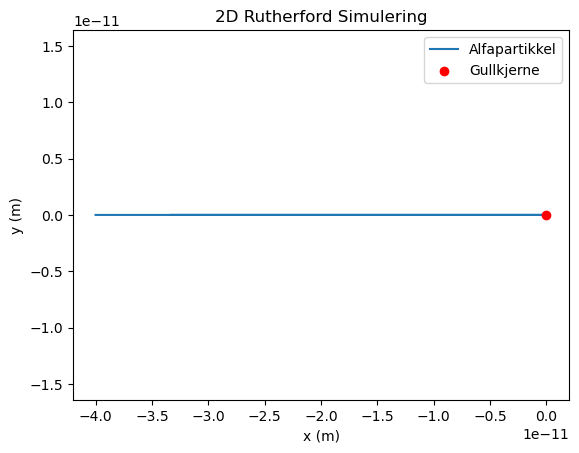

In [41]:
r1, r2, theta = rutherford(0)
print(f"Avbøyningsvinkel: {theta:.2f}°")

fig, ax = plt.subplots()
ax.plot(r2[:, 0], r2[:, 1], label="Alfapartikkel")
ax.scatter(0, 0, color="red", zorder=5, label="Gullkjerne")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("2D Rutherford Simulering")
ax.axis("equal")
ax.legend()
plt.savefig("assets/rutherford2.png", dpi=300)
plt.show()

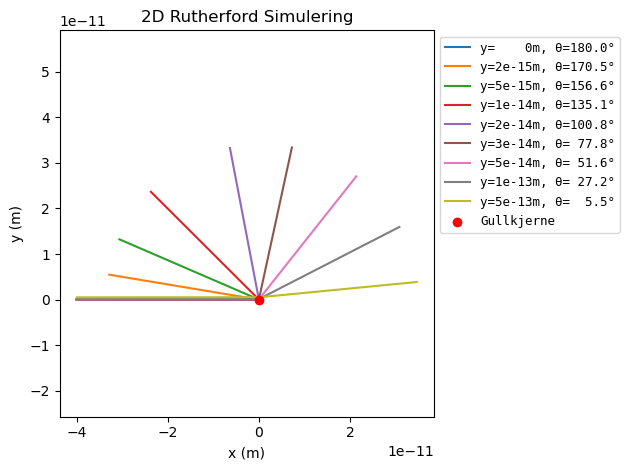

In [66]:
ys = [0, 2e-15, 5e-15, 1e-14, 2e-14, 3e-14, 5e-14, 1e-13, 5e-13]

fig, ax = plt.subplots()
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("2D Rutherford Simulering")
ax.axis("equal")

for y in ys:
    _, r2, theta = rutherford(y)
    ax.plot(r2[:, 0], r2[:, 1], label=f"y={y:>5.0g}m, θ={theta:>5.1f}°")

plt.scatter(0, 0, color="red", zorder=5, label="Gullkjerne")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left", prop={"family": "monospace", "size": 9})
plt.tight_layout()
plt.savefig("assets/rutherford-multi.png", dpi=300)
plt.show()

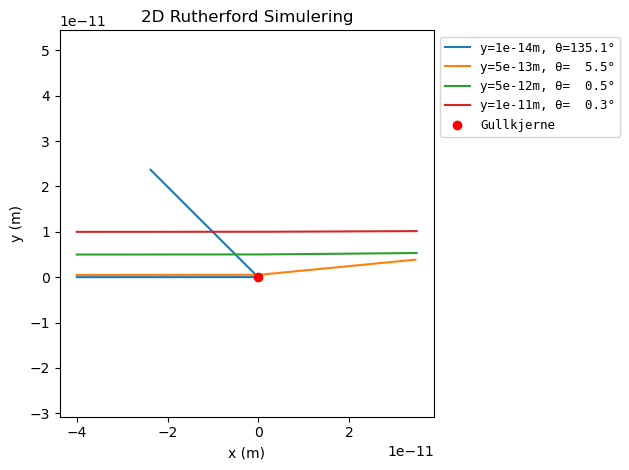

In [73]:
ys = [1e-14, 5e-13, 5e-12, 1e-11]

fig, ax = plt.subplots()
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("2D Rutherford Simulering")
ax.axis("equal")

for y in ys:
    _, r2, theta = rutherford(y)
    ax.plot(r2[:, 0], r2[:, 1], label=f"y={y:>5.0g}m, θ={theta:>5.1f}°")

plt.scatter(0, 0, color="red", zorder=5, label="Gullkjerne")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left", prop={"family": "monospace", "size": 9})
plt.tight_layout()
plt.savefig("assets/rutherford-multi2.png", dpi=300)
plt.show()